## Why is the Test Set Used for Evaluation?

The model is trained using the training dataset (`X_train` and `y_train`).

To measure its real-world performance, the model is evaluated using the test dataset (`X_test` and `y_test`), which contains data that the model has never seen during training.

Evaluating on unseen data helps determine whether the model has learned meaningful patterns instead of simply memorizing the training data. This provides a more reliable estimate of the model's ability to generalize to new data.

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Evaluation Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    auc
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## Load the Dataset

The cleaned dataset is loaded into a Pandas DataFrame for model evaluation.

The target variable (`Depression`) is encoded into numerical values so that it can be used by the Logistic Regression model.

Encoding:

- No → 0
- Yes → 1

In [3]:
# Load the dataset
df = pd.read_csv("../Dataset/Processed/MindSense_AI_Cleaned_Dataset_v1.csv")

# Encode the target variable
df["Depression"] = df["Depression"].map({
    "No": 0,
    "Yes": 1
})

# Display the first five rows
df.head()

,Gender,Age,Working Professional or Student,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,...,Degree_M.Tech,Degree_MA,Degree_MBA,Degree_MBBS,Degree_MCA,Degree_MD,Degree_ME,Degree_MHM,Degree_MSc,Degree_PhD
0,0,37,1,-1.0,2.0,-1.0,-1.0,4.0,2,1,...,0,1,0,0,0,0,0,0,0,0
1,1,60,1,-1.0,4.0,-1.0,-1.0,3.0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,0,42,1,-1.0,2.0,-1.0,-1.0,3.0,1,1,...,0,0,0,0,0,0,0,0,0,0
3,0,44,1,-1.0,3.0,-1.0,-1.0,5.0,2,2,...,0,0,0,0,0,1,0,0,0,0
4,1,48,1,-1.0,4.0,-1.0,-1.0,3.0,2,1,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# Separate features and target variable
X = df.drop("Depression", axis=1)
y = df["Depression"]

In [5]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
# Train the final Logistic Regression model
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [7]:
# Generate predictions
lr_y_pred = lr_model.predict(X_test)

## Classification Report

The Classification Report provides a detailed summary of the Logistic Regression model's performance.

It includes:

- Precision
- Recall
- F1-Score
- Support
- Macro Average
- Weighted Average

These metrics help evaluate the model's performance for each class individually and overall.

In [8]:
# Generate Classification Report
print(classification_report(y_test, lr_y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       429
           1       0.96      0.95      0.96        83

    accuracy                           0.99       512
   macro avg       0.98      0.97      0.97       512
weighted avg       0.99      0.99      0.99       512



## Interpretation of the Classification Report

The Logistic Regression model achieved an overall accuracy of **99%**, indicating excellent predictive performance on the test dataset.

For the **No Depression (Class 0)** category, the model achieved a precision, recall, and F1-score of **99%**, demonstrating highly accurate identification of individuals without depression.

For the **Depression (Class 1)** category, the model achieved a precision of **96%**, recall of **95%**, and F1-score of **96%**. This indicates that the model effectively identifies individuals with depression while maintaining a good balance between false positives and false negatives.

The macro average F1-score of **97%** suggests that the model performs consistently across both classes, whereas the weighted average F1-score of **99%** reflects the larger proportion of samples belonging to the No Depression class.

Overall, the classification report demonstrates that the Logistic Regression model provides reliable and balanced predictions for depression risk classification.

## Confusion Matrix

A Confusion Matrix is a table used to evaluate the performance of a classification model by comparing the actual class labels with the predicted class labels.

It summarizes the predictions into four categories:

- **True Positive (TP):** The model correctly predicts the positive class.
- **True Negative (TN):** The model correctly predicts the negative class.
- **False Positive (FP):** The model incorrectly predicts the positive class for a negative instance.
- **False Negative (FN):** The model incorrectly predicts the negative class for a positive instance.

The Confusion Matrix helps identify not only how many predictions are correct but also the types of errors made by the model.

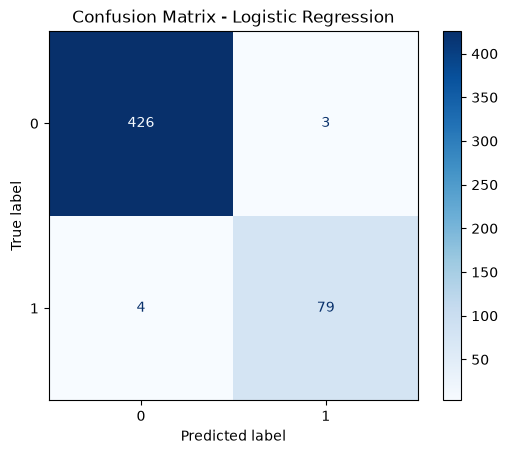

In [9]:
# Generate confusion matrix
cm = confusion_matrix(y_test, lr_y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## Interpretation of the Confusion Matrix

The Confusion Matrix provides a detailed breakdown of the model's predictions.

- **True Negatives (426):** Individuals without depression correctly classified as not having depression.
- **True Positives (79):** Individuals with depression correctly identified by the model.
- **False Positives (3):** Individuals without depression incorrectly predicted as having depression.
- **False Negatives (4):** Individuals with depression incorrectly predicted as not having depression.

The model correctly classified **505 out of 512** test samples, resulting in only **7 misclassifications**.

The low number of false positives and false negatives indicates that the Logistic Regression model provides reliable predictions for depression risk assessment. However, reducing false negatives is particularly important in healthcare applications because missed depression cases may delay timely intervention.

## ROC Curve (Receiver Operating Characteristic)

The ROC Curve is a graphical evaluation metric used to measure the performance of a binary classification model across different classification thresholds.

Unlike accuracy, which evaluates the model at a single threshold (usually 0.5), the ROC Curve shows how the model performs when the decision threshold is varied from 0 to 1.

The ROC Curve plots:

- **True Positive Rate (TPR)** on the Y-axis
- **False Positive Rate (FPR)** on the X-axis

A model with a curve closer to the top-left corner has better classification performance because it achieves a high true positive rate while maintaining a low false positive rate.

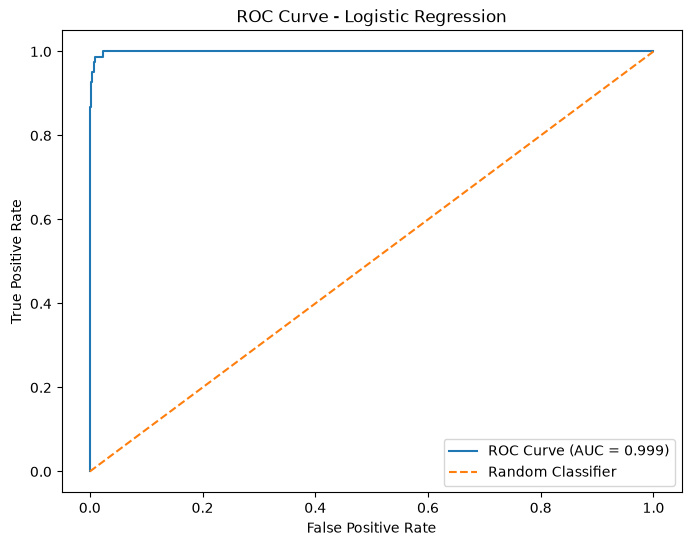

In [11]:
# Predict probabilities for the positive class
lr_y_prob = lr_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, lr_y_prob)

# Calculate AUC score
roc_auc = roc_auc_score(y_test, lr_y_prob)

# Plot ROC Curve
plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

## ROC Curve Interpretation

The ROC Curve evaluates the model's performance across different classification thresholds by comparing the True Positive Rate (TPR) and False Positive Rate (FPR).

The Logistic Regression model achieved an **AUC score of 0.999**, indicating an excellent ability to distinguish between individuals with and without depression.

The ROC curve remains close to the top-left corner of the graph, which demonstrates that the model achieves a high detection rate for depression while maintaining a very low false positive rate.

Overall, the ROC analysis confirms that the Logistic Regression model provides highly reliable classification performance for depression prediction.

## Precision-Recall Curve

The Precision-Recall (PR) Curve evaluates the performance of a binary classification model by illustrating the relationship between **Precision** and **Recall** across different classification thresholds.

Unlike the ROC Curve, the Precision-Recall Curve focuses on the performance of the positive class. It is especially useful when working with imbalanced datasets where the positive class has fewer samples.

A model with a curve closer to the upper-right corner demonstrates better performance by maintaining both high precision and high recall.

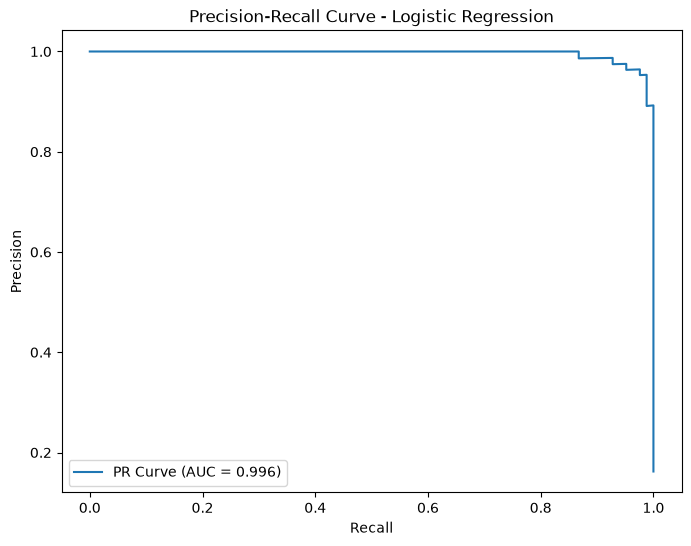

In [12]:
# Calculate Precision-Recall values
precision, recall, thresholds = precision_recall_curve(y_test, lr_y_prob)

# Calculate PR-AUC
pr_auc = auc(recall, precision)

# Plot Precision-Recall Curve
plt.figure(figsize=(8, 6))

plt.plot(recall, precision,
         label=f"PR Curve (AUC = {pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Logistic Regression")
plt.legend()

plt.show()

## Precision-Recall Curve Interpretation

The Precision-Recall Curve evaluates the trade-off between precision and recall across different classification thresholds.

The Logistic Regression model achieved a **PR-AUC score of 0.996**, indicating excellent performance in identifying individuals with depression while maintaining a high level of prediction accuracy.

The curve remains close to the upper-right corner, demonstrating that the model achieves both high precision and high recall over a wide range of thresholds.

Overall, the Precision-Recall analysis confirms that the model is highly effective for depression risk prediction, particularly because it minimizes missed depression cases while keeping false positive predictions low.

## Error Analysis

Although the Logistic Regression model achieved excellent performance, a small number of prediction errors were observed.

From the Confusion Matrix:

- True Negatives (TN): 426
- True Positives (TP): 79
- False Positives (FP): 3
- False Negatives (FN): 4

The model correctly classified **505 out of 512** test samples, resulting in only **7 incorrect predictions**.

Among these errors:

- **False Positives (3):** Individuals without depression were incorrectly classified as having depression.
- **False Negatives (4):** Individuals with depression were incorrectly classified as not having depression.

In the context of mental health prediction, false negatives are generally more concerning because they represent individuals with depression who may not be identified for further assessment or support.

## Strengths of the Model

The Logistic Regression model demonstrated several strengths:

- Achieved an overall accuracy of approximately **99%**.
- Correctly classified **505 out of 512** test samples.
- Achieved an excellent ROC-AUC score of **0.999**.
- Achieved an excellent PR-AUC score of **0.996**.
- Produced very few false positive and false negative predictions.
- Maintained a strong balance between precision and recall.
- Provides fast training and prediction times.
- Produces interpretable results, making it suitable for Explainable AI techniques such as SHAP and LIME.

## Limitations of the Model

Despite its excellent performance, the Logistic Regression model has some limitations:

- The model assumes a linear relationship between the input features and the target variable.
- A small number of false negative predictions still exist, which may be critical in healthcare applications.
- The model was trained and evaluated using a single dataset; its performance on external datasets may differ.
- The model predicts depression risk based on the available features and should not be considered a replacement for professional clinical diagnosis.

## Final Evaluation Summary

The Logistic Regression model demonstrated outstanding performance for depression prediction.

Evaluation results include:

- Accuracy: **99%**
- Precision (Depression): **96%**
- Recall (Depression): **95%**
- F1-Score (Depression): **96%**
- ROC-AUC: **0.999**
- PR-AUC: **0.996**

The model correctly classified **505 out of 512** test samples while producing only **7 misclassifications**.

Overall, the evaluation results indicate that the model is reliable, accurate, and capable of effectively distinguishing between individuals with and without depression. These results support the selection of Logistic Regression as the final model for the MindSense AI framework.